# StayPredict — 01. Exploratory Data Analysis & Target Construction
Educational healthcare dataset exploration for Hospital Length of Stay (LOS) prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Resolve dataset path relative to notebooks directory
DATA_PATH = Path("../data/raw/healthcare_dataset.csv")
print(f"Dataset path: {DATA_PATH.resolve()}")
print(f"File exists: {DATA_PATH.exists()}")


Dataset path: D:\B.E Engineering Content\Sem 7\ML\Mini Project\StayPredict\ml\data\raw\healthcare_dataset.csv
File exists: True


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 55,500 rows, 15 columns


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
print("--- DATASET INFO ---")
df.info()

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(

In [4]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_percent})
print("--- MISSING VALUES AUDIT ---")
print(missing_df[missing_df["Missing Count"] > 0] if missing.sum() > 0 else "No explicit missing values found!")


--- MISSING VALUES AUDIT ---
No explicit missing values found!


In [5]:
num_duplicates = df.duplicated().sum()
print(f"Exact Duplicate Rows: {num_duplicates:,} ({(num_duplicates / len(df)) * 100:.2f}%)")

# Inspect a subset of duplicate rows (original + duplicates) to verify
if num_duplicates > 0:
    duplicates_sample = df[df.duplicated(keep=False)].sort_values(by=list(df.columns[:3])).head(10)
    display(duplicates_sample)


Exact Duplicate Rows: 534 (0.96%)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
42407,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal
54285,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal
26025,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive
53104,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive
42323,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal
50151,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal
21675,ANDREA HansEN,61,Male,O+,Cancer,2021-07-02,Alisha Flores,LLC Clark,Cigna,40026.763948,254,Elective,2021-07-22,Paracetamol,Normal
51695,ANDREA HansEN,61,Male,O+,Cancer,2021-07-02,Alisha Flores,LLC Clark,Cigna,40026.763948,254,Elective,2021-07-22,Paracetamol,Normal
36207,ANDrEA fREnCH,73,Male,A-,Arthritis,2021-02-08,Danny Oconnor,"Taylor Small, Lin and",UnitedHealthcare,9981.590235,323,Elective,2021-02-24,Ibuprofen,Inconclusive
51916,ANDrEA fREnCH,73,Male,A-,Arthritis,2021-02-08,Danny Oconnor,"Taylor Small, Lin and",UnitedHealthcare,9981.590235,323,Elective,2021-02-24,Ibuprofen,Inconclusive


### Decision on Duplicate Records
The dataset contains 534 exact duplicate rows across all 15 columns.
Because identical patient attributes, timestamps, room assignments, and exact 6-decimal billing amounts cannot realistically occur across independent clinical encounters, these represent synthetic sampling duplicates. 
Leaving them in the dataset risks train/test contamination (data leakage). Therefore, we drop exact duplicates.


In [6]:
df_cleaned = df.drop_duplicates().copy()
print(f"Original records: {len(df):,}")
print(f"After dropping duplicates: {len(df_cleaned):,}")
print(f"Rows removed: {len(df) - len(df_cleaned):,}")

Original records: 55,500
After dropping duplicates: 54,966
Rows removed: 534


In [7]:
cardinality = pd.DataFrame({
    'Column': df_cleaned.columns,
    'Data Type': df_cleaned.dtypes.values,
    'Unique Values': [df_cleaned[col].nunique() for col in df_cleaned.columns],
    'Unique Ratio (%)': [(df_cleaned[col].nunique() / len(df_cleaned)) * 100 for col in df_cleaned.columns]
}).sort_values(by='Unique Values', ascending=False).reset_index(drop=True)

print("--- COLUMN CARDINALITY AUDIT ---")
display(cardinality)


--- COLUMN CARDINALITY AUDIT ---


,Column,Data Type,Unique Values,Unique Ratio (%)
0,Billing Amount,float64,50000,90.965324
1,Name,object,49992,90.950770
2,Doctor,object,40341,73.392643
3,Hospital,object,39876,72.546665
4,Discharge Date,object,1856,3.376633
5,Date of Admission,object,1827,3.323873
6,Room Number,int64,400,0.727723
7,Age,int64,77,0.140087
8,Blood Type,object,8,0.014554
9,Medical Condition,object,6,0.010916


In [8]:
print("--- NUMERICAL SUMMARY ---")
display(df_cleaned.describe().T)

print("--- CATEGORICAL SUMMARY ---")
display(df_cleaned.describe(include=['object']).T)

--- NUMERICAL SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
Age,54966.0,51.535185,19.605661,13.00000,35.000000,52.000000,68.000000,89.000000
Billing Amount,54966.0,25544.306284,14208.409711,-2008.49214,13243.718641,25542.749145,37819.858159,52764.276736
Room Number,54966.0,301.124404,115.223143,101.00000,202.000000,302.000000,401.000000,500.000000


--- CATEGORICAL SUMMARY ---


,count,unique,top,freq
Name,54966,49992,DAvId muNoZ,3
Gender,54966,2,Male,27496
Blood Type,54966,8,A-,6898
Medical Condition,54966,6,Arthritis,9218
Date of Admission,54966,1827,2024-03-16,50
Doctor,54966,40341,Michael Smith,27
Hospital,54966,39876,LLC Smith,44
Insurance Provider,54966,5,Cigna,11139
Admission Type,54966,3,Elective,18473
Discharge Date,54966,1856,2020-03-15,53


In [9]:
# Parse string dates to datetime objects
df_cleaned['Date of Admission'] = pd.to_datetime(df_cleaned['Date of Admission'])
df_cleaned['Discharge Date'] = pd.to_datetime(df_cleaned['Discharge Date'])

print("--- DATE RANGE AUDIT ---")
print(f"Admission Date Span: {df_cleaned['Date of Admission'].min().date()} to {df_cleaned['Date of Admission'].max().date()}")
print(f"Discharge Date Span: {df_cleaned['Discharge Date'].min().date()} to {df_cleaned['Discharge Date'].max().date()}")


--- DATE RANGE AUDIT ---
Admission Date Span: 2019-05-08 to 2024-05-07
Discharge Date Span: 2019-05-09 to 2024-06-06


# Phase 3 — Target Construction & Validation
Constructing `Length of Stay` (in days) as `Discharge Date - Date of Admission`.


In [10]:
# Derive Length of Stay in integer days
df_cleaned['Length of Stay'] = (df_cleaned['Discharge Date'] - df_cleaned['Date of Admission']).dt.days

# Target Integrity Checks
negative_stays = (df_cleaned['Length of Stay'] < 0).sum()
zero_stays = (df_cleaned['Length of Stay'] == 0).sum()
null_stays = df_cleaned['Length of Stay'].isnull().sum()

print("--- TARGET INTEGRITY AUDIT ---")
print(f"Negative Stay Records: {negative_stays}")
print(f"Zero-Day Stay Records: {zero_stays}")
print(f"Null Target Records:   {null_stays}")

# Statistical Summary of the Target
los_stats = df_cleaned['Length of Stay'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99])
print("\n--- LENGTH OF STAY (DAYS) SUMMARY ---")
display(los_stats.to_frame().T)


--- TARGET INTEGRITY AUDIT ---
Negative Stay Records: 0
Zero-Day Stay Records: 0
Null Target Records:   0

--- LENGTH OF STAY (DAYS) SUMMARY ---


,count,mean,std,min,25%,50%,75%,90%,99%,max
Length of Stay,54966.0,15.49929,8.661471,1.0,8.0,15.0,23.0,28.0,30.0,30.0


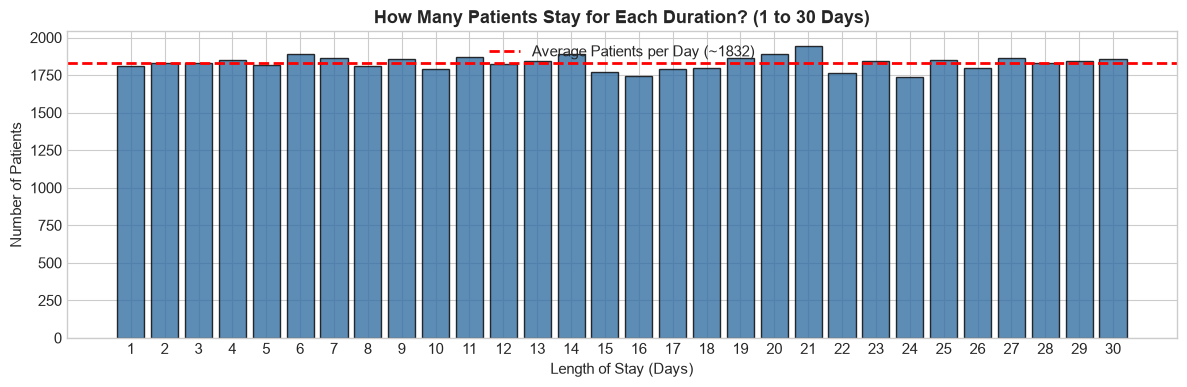

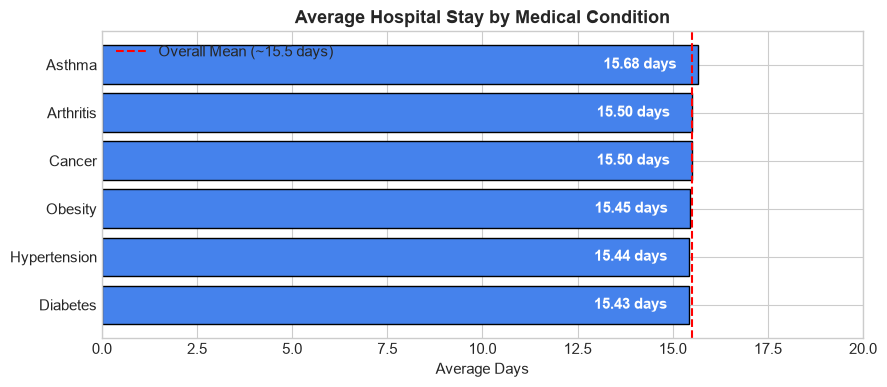

In [11]:
# Simple Plot 1: Exact patient count for each day (1 to 30)
plt.figure(figsize=(12, 4))
day_counts = df_cleaned['Length of Stay'].value_counts().sort_index()

plt.bar(day_counts.index, day_counts.values, color='#3470a3', edgecolor='black', alpha=0.8)
plt.axhline(day_counts.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Average Patients per Day (~{day_counts.mean():.0f})')

plt.title('How Many Patients Stay for Each Duration? (1 to 30 Days)', fontsize=13, fontweight='bold')
plt.xlabel('Length of Stay (Days)', fontsize=11)
plt.ylabel('Number of Patients', fontsize=11)
plt.xticks(range(1, 31))  # Show every day from 1 to 30
plt.legend()
plt.tight_layout()
plt.show()


# Simple Plot 2: Average stay per medical condition
plt.figure(figsize=(9, 4))
avg_stay_by_condition = df_cleaned.groupby('Medical Condition')['Length of Stay'].mean().sort_values()

bars = plt.barh(avg_stay_by_condition.index, avg_stay_by_condition.values, color='#4582ec', edgecolor='black')
plt.axvline(15.5, color='red', linestyle='--', label='Overall Mean (~15.5 days)')

# Add exact day labels on each bar
for bar in bars:
    plt.text(bar.get_width() - 2.5, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.2f} days", 
             va='center', color='white', fontweight='bold')

plt.title('Average Hospital Stay by Medical Condition', fontsize=13, fontweight='bold')
plt.xlabel('Average Days', fontsize=11)
plt.xlim(0, 20)
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# Save validated cleaned dataset with derived target
PROCESSED_DATA_PATH = Path("../data/processed/healthcare_cleaned.csv")
df_cleaned.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Cleaned dataset saved successfully to: {PROCESSED_DATA_PATH.resolve()}")
print(f"Saved Shape: {df_cleaned.shape[0]:,} rows, {df_cleaned.shape[1]} columns")


Cleaned dataset saved successfully to: D:\B.E Engineering Content\Sem 7\ML\Mini Project\StayPredict\ml\data\processed\healthcare_cleaned.csv
Saved Shape: 54,966 rows, 16 columns


# Phase 4 — Data Leakage & Feature Selection Audit

| Feature | Timeline Known | Leakage Risk | Decision | Rationale |
| :--- | :--- | :--- | :--- | :--- |
| **Name** | At Admission | None | **REMOVE** | PII / Arbitrary identifier |
| **Age** | At Admission | None | **KEEP** | Core patient demographic |
| **Gender** | At Admission | None | **KEEP** | Demographic variable |
| **Blood Type** | At Admission | None | **KEEP** | Patient baseline physiological marker |
| **Medical Condition** | At Admission | None | **KEEP** | Primary admitting diagnosis |
| **Date of Admission** | At Admission | None | **TRANSFORM** | Decompose into Year, Month, Day of Week |
| **Doctor** | At Admission | Memorization | **REMOVE** | Extreme cardinality (40,341 unique names) |
| **Hospital** | At Admission | Memorization | **REMOVE** | Extreme cardinality (39,876 unique names) |
| **Insurance Provider**| At Admission | None | **KEEP** | Administrative / triage contextual factor |
| **Billing Amount** | At Discharge | Future Info | **REMOVE** | Accumulates during stay; post-admission financial leakage |
| **Room Number** | At Admission | Spurious | **REMOVE** | Facility room identifier (no generalizable clinical signal) |
| **Admission Type** | At Admission | None | **KEEP** | Triage classification (Emergency, Elective, Urgent) |
| **Discharge Date** | At Discharge | Target Leak | **REMOVE** | Direct mathematical target leakage (Date + Stay = Discharge) |
| **Medication** | During Stay | Future Info | **REMOVE** | Treatment administered after admission |
| **Test Results** | Post Admission | Future Info | **REMOVE** | Laboratory results returned after initial admission |


In [13]:
# Define explicit feature sets based on leakage analysis
TARGET_COL = 'Length of Stay'

FEATURE_COLS = [
    'Age',
    'Gender',
    'Blood Type',
    'Medical Condition',
    'Insurance Provider',
    'Admission Type',
    'Date of Admission'  # To be transformed in Phase 5
]

EXCLUDED_COLS = [
    'Name',
    'Doctor',
    'Hospital',
    'Billing Amount',
    'Room Number',
    'Discharge Date',
    'Medication',
    'Test Results'
]

print("--- FEATURE PARTITION AUDIT ---")
print(f"Target Column:    {TARGET_COL}")
print(f"Candidate Features to Retain ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Excluded Columns ({len(EXCLUDED_COLS)}):         {EXCLUDED_COLS}")

# Verify that all 16 columns of df_cleaned are accounted for
all_accounted = set(FEATURE_COLS + EXCLUDED_COLS + [TARGET_COL]) == set(df_cleaned.columns)
print(f"\nAll dataset columns fully accounted for: {all_accounted}")


--- FEATURE PARTITION AUDIT ---
Target Column:    Length of Stay
Candidate Features to Retain (7): ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Date of Admission']
Excluded Columns (8):         ['Name', 'Doctor', 'Hospital', 'Billing Amount', 'Room Number', 'Discharge Date', 'Medication', 'Test Results']

All dataset columns fully accounted for: True
